# Customer Churn Prediction using Machine Learning

## 1. Business Problem

Customer churn is one of the biggest challenges faced by subscription-based businesses. Losing customers directly impacts revenue and increases customer acquisition costs.

This project analyzes customer demographics and service usage to identify the factors associated with customer churn and builds a machine learning model to predict customer churn.

## 2. Project Objective

The objectives of this project are:

- Understand customer behavior.
- Perform data cleaning and preprocessing.
- Explore patterns associated with customer churn.
- Build predictive machine learning models.
- Generate actionable business insights for improving customer retention.

## 3. Import Required Libraries

In [456]:
import pandas as pd
import matplotlib.pyplot as plt

## 4. Load Dataset

In [457]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

## 5. Data Understanding

Before analysis, it is important to understand the structure and quality of the dataset.

### Preview the Dataset

Display the first five records to understand the structure of the dataset.


In [458]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Observation**

The dataset contains customer demographic information, service details, billing information, and the target variable **Churn**.

### Dataset Dimensions

Check the number of rows and columns.

In [459]:
df.shape

(7043, 21)

**Observation**

The dataset contains **7043 rows** and **21 columns**, providing sufficient data for churn analysis.

### Dataset Information

Inspect data types and identify potential issues.

In [460]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Observation**

Most variables are categorical. MonthlyCharges is already numeric, while TotalCharges is stored as an object and requires conversion.

### Missing Value Analysis

Check whether the dataset contains missing values.

In [461]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Observation**

No missing values are detected initially. However, blank strings exist in TotalCharges and will be handled during preprocessing.

## 6. Data Cleaning

Although the dataset initially appears to have no missing values, the TotalCharges column contains blank strings stored as text. These values are converted to numeric format and replaced using the median. The customerID column is also removed because it does not contribute to predicting customer churn.

In [462]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

In [463]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [464]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [465]:
df.drop("customerID", axis=1, inplace=True)

In [466]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


### Data Cleaning Summary

- TotalCharges successfully converted to numeric.
- Missing values handled using median imputation.
- customerID removed.
- The dataset is now clean, consistent, and ready for exploratory data analysis and machine learning.

## 7. Exploratory Data Analysis (EDA)

EDA is performed to identify patterns and relationships between customer characteristics and churn.

### 7.1 Contract Type vs Customer Churn

**Question:** Does the type of customer contract influence the likelihood of customer churn?

In [467]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [468]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [469]:
contract_churn = pd.crosstab(df["Contract"],df["Churn"],normalize="index") * 100
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Visualization

A bar chart is created to compare the churn percentage across different contract types and identify which customers are more likely to leave.

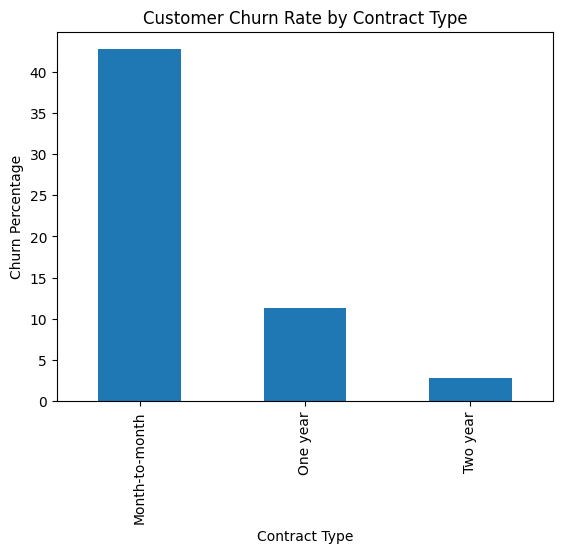

In [470]:
contract_churn["Yes"].plot(kind="bar")
plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Percentage")
plt.show()

### Business Insight

- Customers with month-to-month contracts have the highest churn rate (42.7%).
- Customers with one-year contracts show a much lower churn rate (11.3%).
- Customers with two-year contracts have the lowest churn rate (2.8%).

**Recommendation**

The company should encourage customers to switch from month-to-month contracts to longer-term contracts through discounts, loyalty programs, or bundled offers to improve customer retention.

### Conclusion

The analysis confirms that contract type has a significant impact on customer churn. Customers with longer contract durations are much less likely to churn compared to customers on month-to-month contracts.

### 7.2 Business Question

#### Does the type of internet service influence customer churn?

In [471]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [472]:
pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [473]:
internet_churn = pd.crosstab(df["InternetService"],df["Churn"],normalize="index") * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


### Visualization

The following chart compares customer churn percentages across different internet service types.

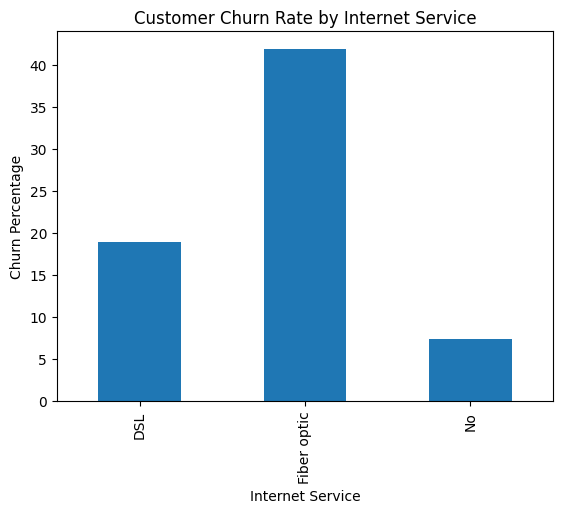

In [474]:
internet_churn["Yes"].plot(kind="bar")

plt.title("Customer Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Percentage")

plt.show()

### Business Insight

- Customers using **Fiber optic** internet service have the highest churn rate (**41.9%**), indicating they are the most likely to discontinue the service.
- Customers using **DSL** have a considerably lower churn rate (**19.0%**).
- Customers with **no internet service** have the lowest churn rate (**7.4%**), suggesting they are less likely to leave.

These findings indicate that customers subscribed to Fiber optic internet are at a significantly higher risk of churning compared to other customer groups.

### Conclusion

The analysis shows that the type of internet service has a significant impact on customer churn. Fiber optic customers exhibit the highest churn rate, making them an important customer segment for retention strategies. The company should investigate factors such as pricing, service quality, network reliability, and customer support to reduce churn among Fiber optic users.

In [475]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [476]:
payment_churn = pd.crosstab(df["PaymentMethod"],df["Churn"],normalize="index") * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


### Visualization

The following chart compares customer churn percentages across different payment methods.

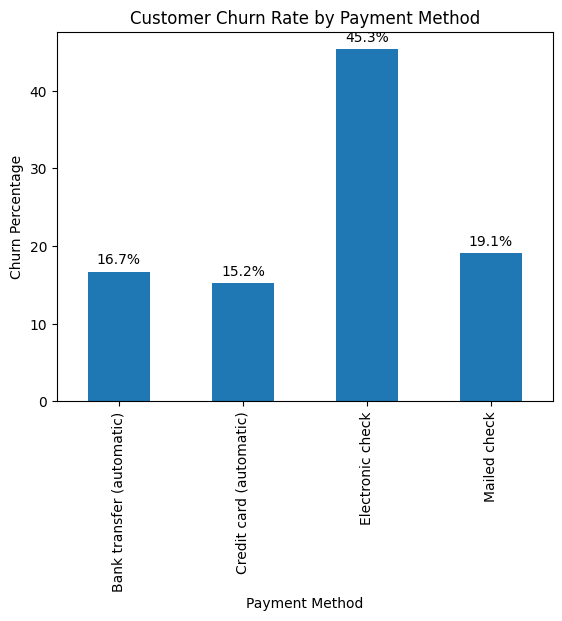

In [477]:
payment_churn["Yes"].plot(kind="bar")

plt.title("Customer Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Percentage")

for i, value in enumerate(payment_churn["Yes"]):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

### Business Insight

- Customers who use **Electronic check** have the highest churn rate (**45.3%**), making them the most likely to leave the company.
- Customers using **Credit card (automatic)** have the lowest churn rate (**15.2%**).
- Customers paying through **Bank transfer (automatic)** also show a relatively low churn rate (**16.7%**).
- Customers using **Mailed check** have a moderate churn rate (**19.1%**).

These findings indicate that customers using automatic payment methods are more likely to remain with the company, whereas customers paying through Electronic check are at a much higher risk of churning.

### Conclusion

The analysis confirms that payment method significantly influences customer churn. Customers using Electronic check experience the highest churn rate, while those enrolled in automatic payment methods are more likely to stay. Encouraging customers to switch to automatic payment options may improve customer retention and reduce churn.

### 7.4 Business Question

#### Does customer tenure influence customer churn?

In [478]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [479]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [480]:
df.groupby("Churn")["tenure"].median()

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

### Visualization

The following box plot compares customer tenure between customers who churned and those who did not.

<Figure size 600x500 with 0 Axes>

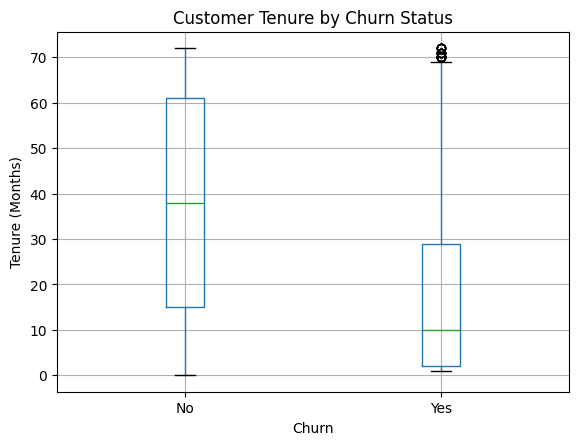

In [481]:
plt.figure(figsize=(6,5))

df.boxplot(column="tenure", by="Churn")

plt.title("Customer Tenure by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

### Business Insight

- Customers who **did not churn** stayed with the company for an average of **37.6 months**, while customers who **churned** stayed for only **18.0 months**.
- The median tenure of churned customers is **10 months**, compared to **38 months** for retained customers.
- The box plot shows that churned customers generally have much shorter tenures, although a few long-term customers also leave.

These findings indicate that customer tenure is one of the strongest indicators of churn. Customers who have recently joined are significantly more likely to discontinue the service.

### Conclusion

Customer tenure has a strong negative relationship with customer churn. Customers with longer service durations are more loyal and less likely to leave the company, whereas newer customers face the highest risk of churn. Businesses should focus on improving customer experience during the first year through onboarding programs, loyalty rewards, and proactive customer support to increase retention.

## 7.5 Business Question

### Do monthly charges influence customer churn?

In [482]:
df["MonthlyCharges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [483]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [484]:
df.groupby("Churn")["MonthlyCharges"].median()

Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64

### Visualization

The following box plot compares monthly charges between customers who churned and those who did not.

<Figure size 600x500 with 0 Axes>

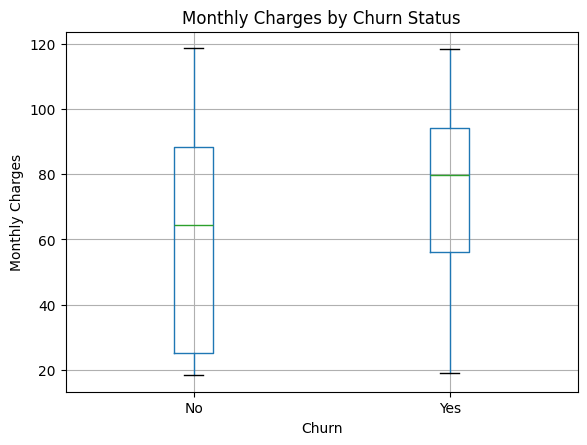

In [485]:
plt.figure(figsize=(6,5))

df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

### Business Insight

- Customers who churned have an average monthly charge of **$74.44**, while retained customers pay an average of **$61.27**.
- The median monthly charge is **$79.65** for churned customers compared with **$64.43** for retained customers.
- The box plot shows that customers with higher monthly charges are more likely to churn.

These findings suggest that customers paying higher monthly bills have a greater likelihood of leaving the company.

### Conclusion

Monthly charges have a positive relationship with customer churn. Customers with higher monthly charges tend to leave the company more frequently than those paying lower monthly charges. Businesses should review pricing strategies, provide competitive plans, and offer discounts or value-added services to reduce churn among high-paying customers.

## 7.6 Business Question

### Does online security influence customer churn?

In [486]:
df["OnlineSecurity"].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [487]:
pd.crosstab(df["OnlineSecurity"],df["Churn"])

Churn,No,Yes
OnlineSecurity,,
No,2037,1461
No internet service,1413,113
Yes,1724,295


In [488]:
Security_Churn=pd.crosstab(df["OnlineSecurity"],df["Churn"],normalize="index")*100

Security_Churn

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


### Visualization

The following chart compares customer churn percentages across different online security service options.

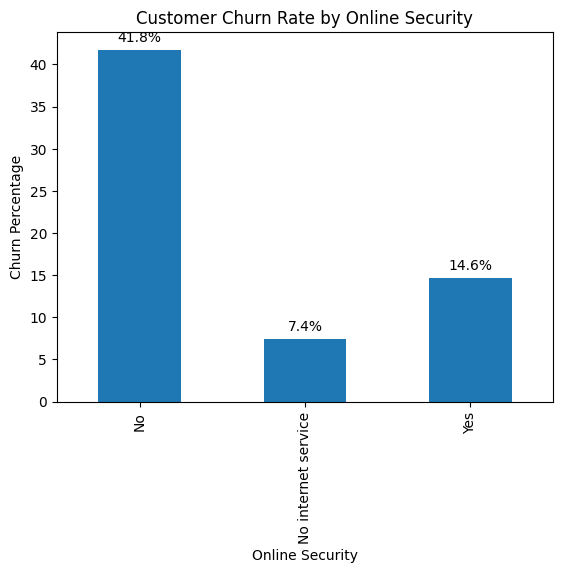

In [489]:
Security_Churn["Yes"].plot(kind="bar")

plt.title("Customer Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Percentage")

for i, value in enumerate(Security_Churn["Yes"]):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

### Business Insight

- Customers **without Online Security** have the highest churn rate at **41.8%**.
- Customers **with Online Security** have a much lower churn rate of **14.6%**.
- Customers with **No Internet Service** have the lowest churn rate (**7.4%**) since they do not subscribe to internet-related services.

These findings indicate that customers who do not use Online Security are nearly three times more likely to leave the company than those who have the service.

### Conclusion

Online Security is a strong factor influencing customer churn. Customers who subscribe to Online Security are significantly more likely to remain with the company, whereas customers without this service exhibit much higher churn rates. Promoting Online Security through bundled plans or introductory offers may help improve customer retention and reduce churn.

## 7.7 Business Question

### Does technical support influence customer churn?

In [490]:
df["TechSupport"].value_counts()

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [491]:
pd.crosstab(df["TechSupport"], df["Churn"])

Churn,No,Yes
TechSupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


In [492]:
tech_churn = pd.crosstab(df["TechSupport"],df["Churn"],normalize="index") * 100

tech_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


### Visualization

The following chart compares customer churn percentages across different technical support service options.

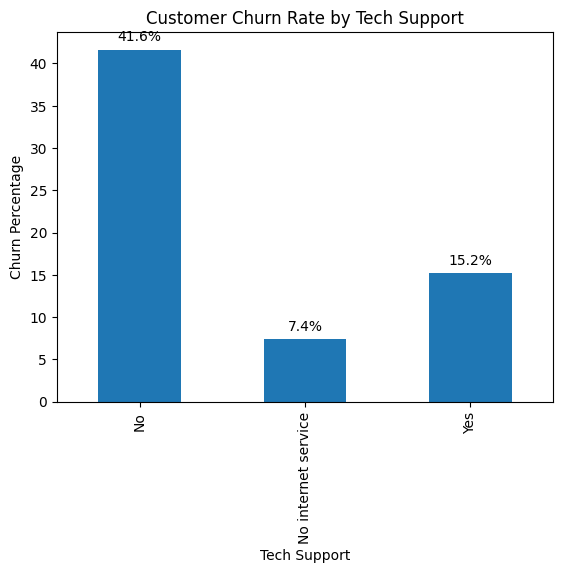

In [493]:
tech_churn["Yes"].plot(kind="bar")

plt.title("Customer Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Percentage")

for i, value in enumerate(tech_churn["Yes"]):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

### Business Insight

- Customers **without Tech Support** have the highest churn rate at **41.6%**.
- Customers **with Tech Support** have a much lower churn rate of **15.2%**.
- Customers with **No Internet Service** have the lowest churn rate (**7.4%**) because they do not subscribe to internet-related services.

These findings suggest that customers who do not receive technical support are almost three times more likely to leave the company than those who have access to technical support.

### Conclusion

Technical Support is strongly associated with customer retention. Customers who receive technical support are significantly less likely to churn, while customers without technical support show much higher churn rates. Encouraging customers to subscribe to technical support services may improve customer satisfaction and reduce customer churn.

# 8. Data Preprocessing for Machine Learning

Machine learning algorithms require numerical input data. This section prepares the dataset by separating the target variable, encoding categorical features, and creating training and testing datasets.

## 8.1 Define Features and Target

The target variable is **Churn**, while all remaining columns are used as predictor variables.

In [494]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (7043, 19)
Target Vector Shape: (7043,)


## 8.2 Encode Categorical Variables

Categorical variables are converted into numerical format using one-hot encoding.

In [495]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


### Encoded Dataset

The categorical variables have now been converted into binary numerical columns suitable for machine learning.

## 8.3 Encode Target Variable

The target variable is converted into numerical values where:

- No → 0
- Yes → 1

In [496]:
y = y.map({"No":0,"Yes":1})

y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

### Target Encoding Summary

The target variable is now in binary format and ready for supervised learning.

## 8.4 Train-Test Split

The dataset is divided into training and testing datasets.

- Training Data : 80%
- Testing Data : 20%

The training data is used to build the model, while the testing data is used to evaluate its performance on unseen observations.

In [497]:
from sklearn.model_selection import train_test_split

In [498]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [499]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Training Features : (5634, 30)
Testing Features  : (1409, 30)
Training Target : (5634,)
Testing Target  : (1409,)


### Dataset Split Summary

The dataset has been successfully divided into training and testing datasets and is now ready for machine learning model development.

# 9. Machine Learning Model Building

This section develops multiple machine learning models to predict customer churn. The performance of each model will be evaluated and compared using standard classification metrics.

## 9.1 Import Required Libraries

The following libraries are imported to build, train, and evaluate machine learning models.

In [500]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 9.2 Logistic Regression

Logistic Regression is used as a baseline classification model for predicting customer churn.

In [501]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

C:\Users\Naveen Kumar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [502]:
lr_pred = lr.predict(X_test)

### Model Accuracy

In [503]:
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(lr_accuracy*100,2),"%")

Logistic Regression Accuracy: 82.04 %


### Confusion Matrix

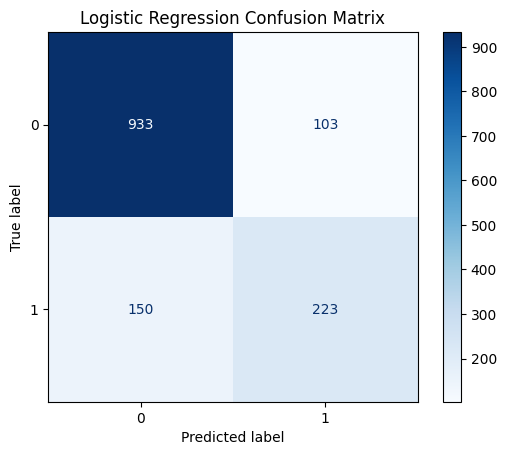

In [504]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Classification Report

In [505]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



### Business Insight

Logistic Regression provides a strong baseline model for predicting customer churn. It helps classify customers into churn and non-churn groups and serves as a benchmark for comparing more advanced machine learning models.

## 9.3 Decision Tree

Decision Tree is a non-linear supervised learning algorithm that predicts customer churn by learning decision rules from the training data.

In [506]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

### Model Accuracy

In [507]:
dt_pred = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", round(dt_accuracy*100,2),"%")

Decision Tree Accuracy: 70.97 %


### Confusion Matrix

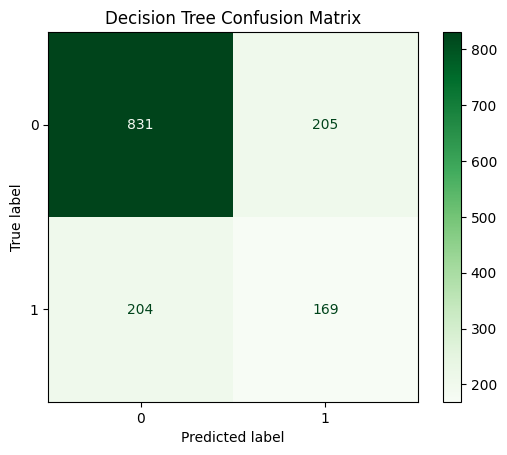

In [508]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

### Classification Report

In [509]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80      1036
           1       0.45      0.45      0.45       373

    accuracy                           0.71      1409
   macro avg       0.63      0.63      0.63      1409
weighted avg       0.71      0.71      0.71      1409



### Business Insight

The Decision Tree model captures complex decision rules within customer data and provides interpretable predictions. Its performance is compared with Logistic Regression to determine whether a tree-based model improves churn prediction.

## 9.4 Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [510]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [511]:
rf_pred = rf.predict(X_test)

### Model Accuracy

In [512]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy*100,2),"%")

Random Forest Accuracy: 78.92 %


### Confusion Matrix

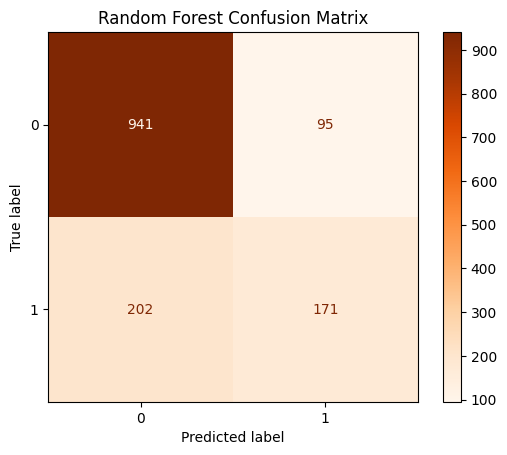

In [513]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

### Classification Report

In [514]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



### Business Insight

Random Forest improves prediction performance by combining multiple decision trees, reducing overfitting and increasing model stability. It generally provides better accuracy and more reliable churn predictions than a single Decision Tree.

## 9.5 Model Comparison

The performance of the three machine learning models is compared using classification accuracy.

In [515]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy (%)": [
        round(lr_accuracy*100,2),
        round(dt_accuracy*100,2),
        round(rf_accuracy*100,2)
    ]
})

comparison

,Model,Accuracy (%)
0,Logistic Regression,82.04
1,Decision Tree,70.97
2,Random Forest,78.92


### Visualization

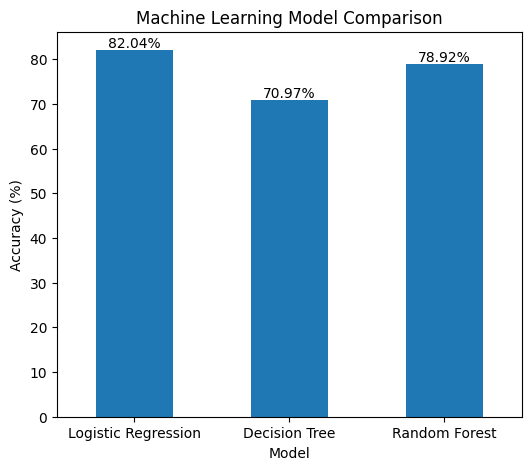

In [516]:
comparison.plot(
    x="Model",
    y="Accuracy (%)",
    kind="bar",
    legend=False,
    figsize=(6,5)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=0)

for i, value in enumerate(comparison["Accuracy (%)"]):
    plt.text(i, value+0.5, f"{value:.2f}%", ha="center")

plt.show()

### Final Business Insight

Among the three machine learning models, Logistic Regression achieved the highest prediction accuracy (82.04%) and demonstrated the best overall balance of precision, recall, and F1-score for customer churn prediction. Although Random Forest also performed reasonably well, its overall performance was slightly lower than Logistic Regression, while Decision Tree recorded the lowest predictive accuracy.

Based on the evaluation results, Logistic Regression is selected as the most suitable model for predicting customer churn in this study. The model can help businesses identify customers who are likely to discontinue their services, allowing organizations to implement targeted retention strategies, improve customer satisfaction, and reduce customer attrition.